In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, mean_absolute_error, classification_report
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from torch.utils.data import Dataset
import os
import time
from datetime import timedelta
import sys
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используемое устройство: {device}")

Используемое устройство: cuda


In [7]:
class CEFRDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=256):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = int(self.labels[idx]) - 1

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

In [8]:
df = pd.read_csv('ru_cefr_short.csv')
df['label'] = df['textbook-assigned cefr level'].astype(int)
df

,fragment,textbook-assigned cefr level,label
0,"Весной, летом и осенью почти каждую субботу он...",1,1
1,"Все говорят, что мама хорошая хозяйка. А ещё н...",1,1
2,На каждой двери красные плакаты и красные фона...,1,1
3,"Я считаю деньги, в час обедаю в кафе, а потом ...",1,1
4,Магазин «Чёрный квадрат» открывается в 9 часов...,1,1
...,...,...,...
7317,Утечка мозгов стала ключевым трендом междунаро...,6,6
7318,"По оценкам менеджеров «Промы», такая ситуация ...",6,6
7319,"Но это не мы, а техно-мемы заполоняют мир благ...",6,6
7320,Mapillary использует программное обеспечение д...,6,6


In [9]:
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['fragment'].values,
    df['label'].values,
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

print(f"Размер обучающей выборки без аугментаций: {len(train_texts)}")
print(f"Размер валидационной выборки без аугментаций: {len(val_texts)}")

Размер обучающей выборки без аугментаций: 5857
Размер валидационной выборки без аугментаций: 1465


In [10]:
def fit(c2):
    model_name = 'sberbank-ai/ruBert-large'
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=6,
        id2label={0: 'A1', 1: 'A2', 2: 'B1', 3: 'B2', 4: 'C1', 5: 'C2'},
        label2id={'A1': 0, 'A2': 1, 'B1': 2, 'B2': 3, 'C1': 4, 'C2': 5}
    )
    
    model = model.to(device)
    print(f"Модель инициализирована")

    
    train_labels_aug = train_labels.tolist() + [6]*len(c2)
    train_texts_aug = train_texts.tolist() + c2['generated-text'].tolist()
    
    train_dataset = CEFRDataset(train_texts_aug, train_labels_aug, tokenizer)
    val_dataset = CEFRDataset(val_texts, val_labels, tokenizer)
    
    print(f"Обучающая выборка с аугментациями: {len(train_texts_aug)}")
    print(f"Валидационная выборка без аугментации: {len(val_texts)}")

    training_args = TrainingArguments(
        num_train_epochs=3,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        warmup_steps=100,
        weight_decay=0.01,
        logging_steps=100,
        eval_strategy='epoch',
        save_strategy='epoch',
        load_best_model_at_end=True,
        metric_for_best_model='eval_loss',
        greater_is_better=False,
        learning_rate=2e-5
    )
    
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
    )

    train_start_time = time.time()
    trainer.train()
    train_time = time.time() - train_start_time
    print(f"Обучение завершено за {train_time:.2f} секунд ({timedelta(seconds=int(train_time))})")

    return model, val_dataset, train_time
    

In [11]:
def predict(model, val_dataset, device, train_time):
    model.eval()
    predictions = []
    true_labels = []

    with torch.no_grad():
        for i in range(len(val_dataset)):
            batch = val_dataset[i]
            
            inputs = {
                'input_ids': batch['input_ids'].unsqueeze(0).to(device),
                'attention_mask': batch['attention_mask'].unsqueeze(0).to(device)
            }
            
            outputs = model(**inputs)
            pred = torch.argmax(outputs.logits, dim=1).item()
            predictions.append(pred + 1)  
            true_labels.append(batch['labels'].item() + 1)  

    accuracy = accuracy_score(true_labels, predictions)
    f1_micro = f1_score(true_labels, predictions, average="micro")
    f1_macro = f1_score(true_labels, predictions, average="macro")
    f1_weighted = f1_score(true_labels, predictions, average="weighted")
    mae = mean_absolute_error(true_labels, predictions)
    
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1 Micro: {f1_micro:.4f}")
    print(f"F1 Macro: {f1_macro:.4f}")
    print(f"F1 Weighted: {f1_weighted:.4f}")
    print(f"MAE: {mae:.4f}")
    print(classification_report(true_labels, predictions))

    print(f"\n\n{accuracy:.4f}\n{f1_micro:.4f}\n{f1_macro:.4f}\n{f1_weighted:.4f}\n{mae:.4f}\n{train_time:.2f}")
    
    return true_labels, predictions

In [12]:
def visualize_cm(true_labels, predictions):
    cm = confusion_matrix(true_labels, predictions)

    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(cm, cmap='Blues')
    
    ax.set_xticks(range(6))
    ax.set_yticks(range(6))
    ax.set_xticklabels(['A1', 'A2', 'B1', 'B2', 'C1', 'C2'])
    ax.set_yticklabels(['A1', 'A2', 'B1', 'B2', 'C1', 'C2'])
    
    for i in range(6):
        for j in range(6):
            ax.text(j, i, cm[i, j], ha='center', va='center')
    
    plt.xlabel('Предсказанные')
    plt.ylabel('Истинные')
    plt.title('Матрица ошибок')
    plt.colorbar(im)
    plt.show()
    

# Температура 0.0

In [13]:
c2 = pd.read_csv('c2_generated_llama3_temp_0_0.csv')
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,1.027100,0.981201
2,0.534900,0.994690
3,0.116900,1.389124


Обучение завершено за 323.05 секунд (0:05:23)


In [14]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6075
F1 Micro: 0.6075
F1 Macro: 0.5310
F1 Weighted: 0.6030
MAE: 0.4696
              precision    recall  f1-score   support

           1       0.88      0.49      0.63       153
           2       0.48      0.78      0.60       227
           3       0.60      0.68      0.63       475
           4       0.67      0.52      0.59       343
           5       0.67      0.57      0.62       237
           6       1.00      0.07      0.12        30

    accuracy                           0.61      1465
   macro avg       0.72      0.52      0.53      1465
weighted avg       0.65      0.61      0.60      1465



0.6075
0.6075
0.5310
0.6030
0.4696
323.05


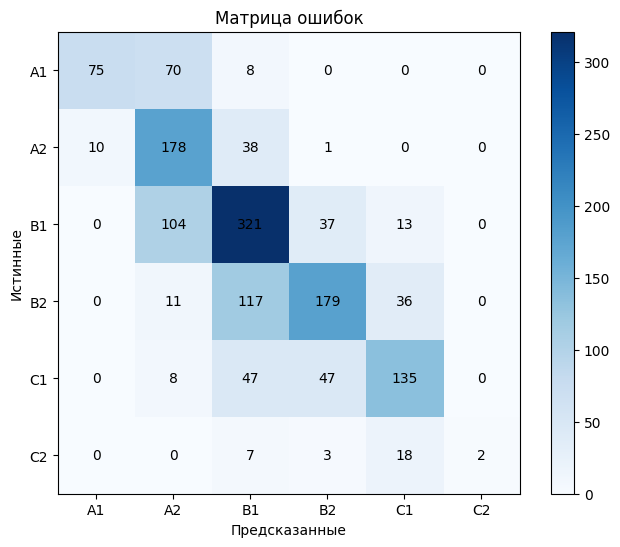

In [15]:
visualize_cm(true_labels, predictions)

# Температура 0.1

In [16]:
c2 = pd.read_csv('c2_generated_llama3_temp_0_1.csv')
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,1.026300,0.962968
2,0.540500,1.062079
3,0.131000,1.408689


Обучение завершено за 328.51 секунд (0:05:28)


In [17]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6075
F1 Micro: 0.6075
F1 Macro: 0.5115
F1 Weighted: 0.5999
MAE: 0.4621
              precision    recall  f1-score   support

           1       0.90      0.41      0.56       153
           2       0.51      0.75      0.61       227
           3       0.62      0.69      0.65       475
           4       0.60      0.57      0.58       343
           5       0.64      0.57      0.60       237
           6       0.50      0.03      0.06        30

    accuracy                           0.61      1465
   macro avg       0.63      0.50      0.51      1465
weighted avg       0.63      0.61      0.60      1465



0.6075
0.6075
0.5115
0.5999
0.4621
328.51


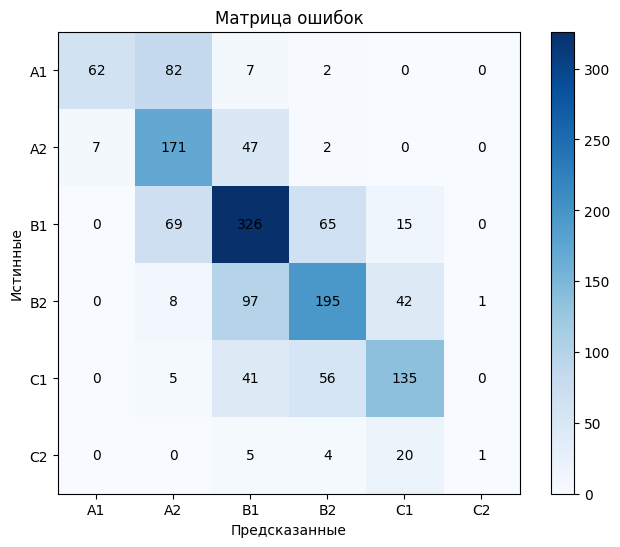

In [18]:
visualize_cm(true_labels, predictions)

# Температура 0.2

In [19]:
c2 = pd.read_csv('c2_generated_llama3_temp_0_2.csv')
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,1.019800,0.954171
2,0.539100,1.049758
3,0.147700,1.449757


Обучение завершено за 328.22 секунд (0:05:28)


In [20]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6164
F1 Micro: 0.6164
F1 Macro: 0.5251
F1 Weighted: 0.6108
MAE: 0.4553
              precision    recall  f1-score   support

           1       0.90      0.49      0.64       153
           2       0.53      0.74      0.62       227
           3       0.62      0.70      0.66       475
           4       0.62      0.56      0.58       343
           5       0.64      0.56      0.60       237
           6       0.14      0.03      0.05        30

    accuracy                           0.62      1465
   macro avg       0.58      0.51      0.53      1465
weighted avg       0.63      0.62      0.61      1465



0.6164
0.6164
0.5251
0.6108
0.4553
328.22


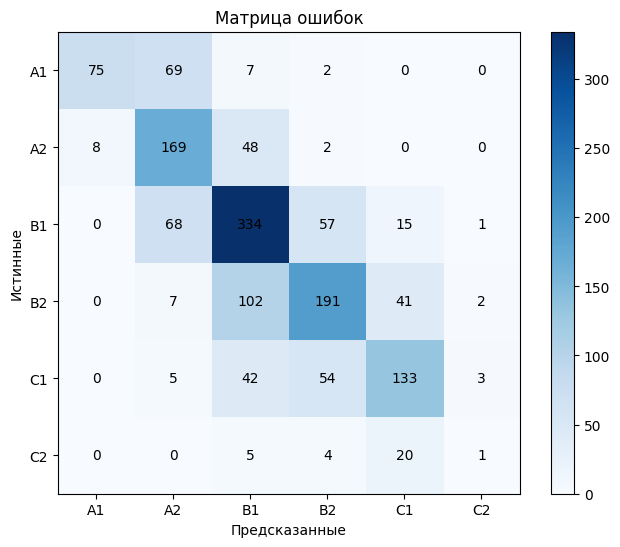

In [21]:
visualize_cm(true_labels, predictions)

# Температура 0.4

In [22]:
c2 = pd.read_csv('c2_generated_llama3_temp_0_4.csv')
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,1.026600,0.960870
2,0.530000,1.051450
3,0.128100,1.411850


Обучение завершено за 328.25 секунд (0:05:28)


In [23]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6184
F1 Micro: 0.6184
F1 Macro: 0.5274
F1 Weighted: 0.6117
MAE: 0.4532
              precision    recall  f1-score   support

           1       0.92      0.46      0.62       153
           2       0.52      0.78      0.63       227
           3       0.62      0.69      0.65       475
           4       0.61      0.56      0.59       343
           5       0.66      0.58      0.62       237
           6       1.00      0.03      0.06        30

    accuracy                           0.62      1465
   macro avg       0.72      0.52      0.53      1465
weighted avg       0.65      0.62      0.61      1465



0.6184
0.6184
0.5274
0.6117
0.4532
328.25


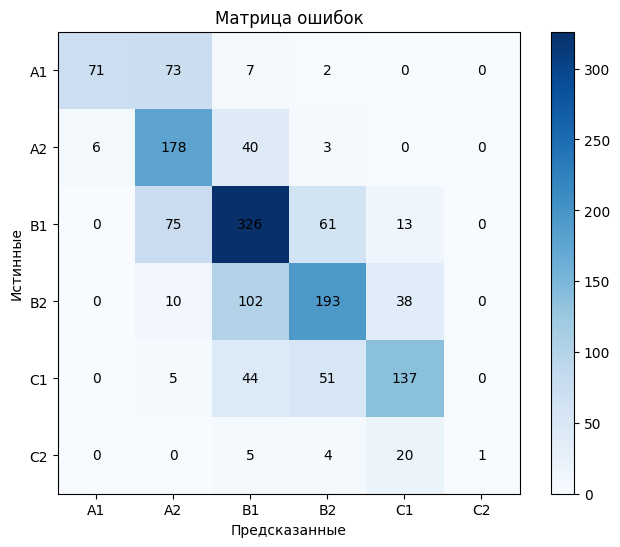

In [24]:
visualize_cm(true_labels, predictions)

# Температура 0.5

In [25]:
c2 = pd.read_csv('c2_generated_llama3_temp_0_5.csv')
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,1.026900,0.963196
2,0.533900,1.041302
3,0.129600,1.433100


Обучение завершено за 328.35 секунд (0:05:28)


In [26]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6191
F1 Micro: 0.6191
F1 Macro: 0.5271
F1 Weighted: 0.6136
MAE: 0.4580
              precision    recall  f1-score   support

           1       0.91      0.47      0.62       153
           2       0.52      0.79      0.63       227
           3       0.63      0.68      0.65       475
           4       0.63      0.57      0.60       343
           5       0.65      0.57      0.61       237
           6       0.14      0.03      0.05        30

    accuracy                           0.62      1465
   macro avg       0.58      0.52      0.53      1465
weighted avg       0.64      0.62      0.61      1465



0.6191
0.6191
0.5271
0.6136
0.4580
328.35


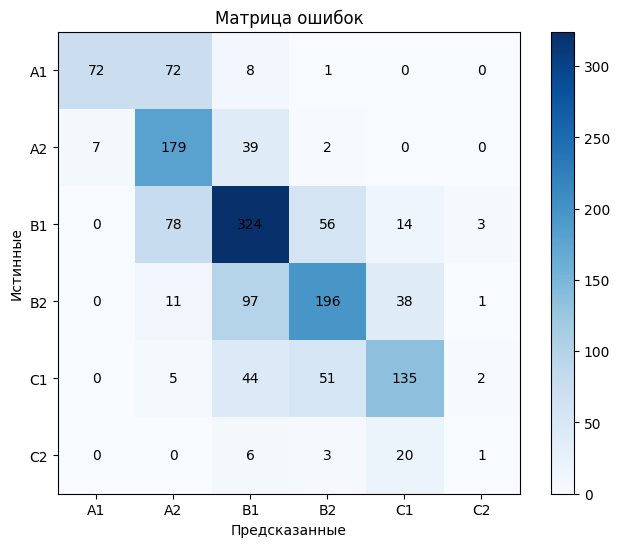

In [27]:
visualize_cm(true_labels, predictions)

# Температура 0.6

In [28]:
c2 = pd.read_csv('c2_generated_llama3_temp_0_6.csv')
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,1.023100,0.953387
2,0.526900,1.040950
3,0.143100,1.448578


Обучение завершено за 328.20 секунд (0:05:28)


In [29]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6177
F1 Micro: 0.6177
F1 Macro: 0.5392
F1 Weighted: 0.6129
MAE: 0.4553
              precision    recall  f1-score   support

           1       0.89      0.44      0.59       153
           2       0.52      0.77      0.62       227
           3       0.63      0.68      0.65       475
           4       0.62      0.58      0.60       343
           5       0.65      0.59      0.62       237
           6       0.38      0.10      0.16        30

    accuracy                           0.62      1465
   macro avg       0.61      0.53      0.54      1465
weighted avg       0.64      0.62      0.61      1465



0.6177
0.6177
0.5392
0.6129
0.4553
328.20


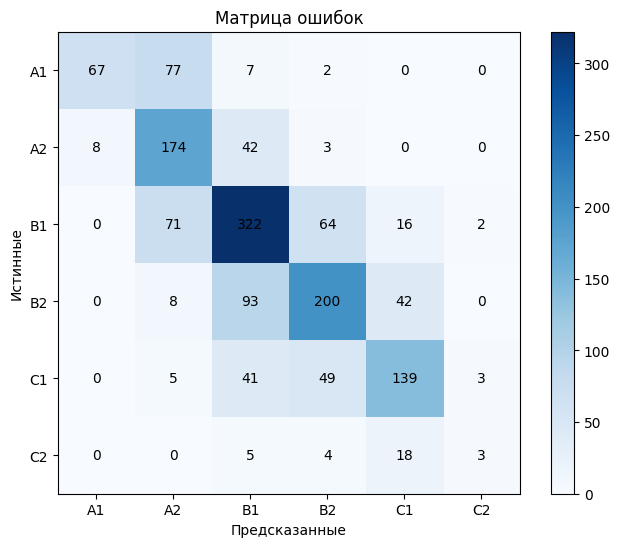

In [30]:
visualize_cm(true_labels, predictions)

# Температура 0.7

In [31]:
c2 = pd.read_csv('c2_generated_llama3_temp_0_7.csv')
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,1.025900,0.966572
2,0.529900,1.019641
3,0.140400,1.427285


Обучение завершено за 328.21 секунд (0:05:28)


In [32]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6102
F1 Micro: 0.6102
F1 Macro: 0.5249
F1 Weighted: 0.6042
MAE: 0.4642
              precision    recall  f1-score   support

           1       0.92      0.42      0.58       153
           2       0.51      0.78      0.62       227
           3       0.62      0.68      0.65       475
           4       0.62      0.57      0.59       343
           5       0.64      0.57      0.60       237
           6       0.33      0.07      0.11        30

    accuracy                           0.61      1465
   macro avg       0.61      0.51      0.52      1465
weighted avg       0.63      0.61      0.60      1465



0.6102
0.6102
0.5249
0.6042
0.4642
328.21


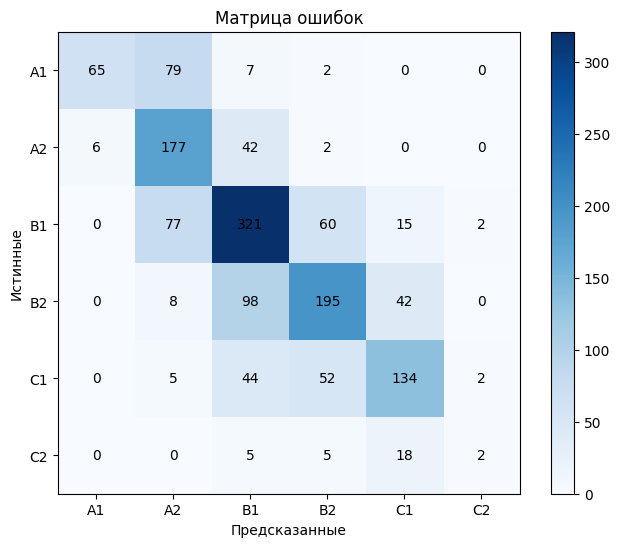

In [33]:
visualize_cm(true_labels, predictions)

# Температура 0.8

In [34]:
c2 = pd.read_csv('c2_generated_llama3_temp_0_8.csv')
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,1.019600,0.955098
2,0.532300,1.017123
3,0.138800,1.438069


Обучение завершено за 328.38 секунд (0:05:28)


In [35]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6239
F1 Micro: 0.6239
F1 Macro: 0.5431
F1 Weighted: 0.6188
MAE: 0.4451
              precision    recall  f1-score   support

           1       0.92      0.50      0.64       153
           2       0.55      0.76      0.63       227
           3       0.63      0.69      0.66       475
           4       0.60      0.57      0.59       343
           5       0.65      0.59      0.62       237
           6       0.50      0.07      0.12        30

    accuracy                           0.62      1465
   macro avg       0.64      0.53      0.54      1465
weighted avg       0.64      0.62      0.62      1465



0.6239
0.6239
0.5431
0.6188
0.4451
328.38


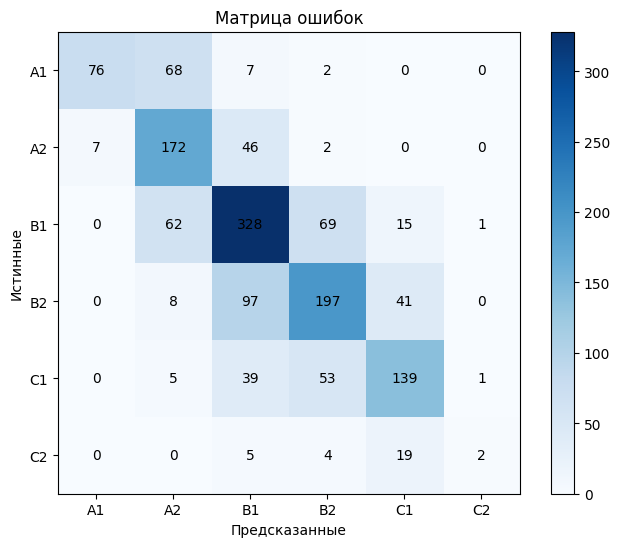

In [36]:
visualize_cm(true_labels, predictions)

# Температура 0.9

In [37]:
c2 = pd.read_csv('c2_generated_llama3_temp_0_9.csv')
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,1.021600,0.955845
2,0.536800,1.047985
3,0.141800,1.458242


Обучение завершено за 328.38 секунд (0:05:28)


In [38]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6273
F1 Micro: 0.6273
F1 Macro: 0.5294
F1 Weighted: 0.6203
MAE: 0.4471
              precision    recall  f1-score   support

           1       0.91      0.44      0.59       153
           2       0.53      0.74      0.62       227
           3       0.63      0.72      0.67       475
           4       0.64      0.59      0.61       343
           5       0.65      0.60      0.63       237
           6       0.33      0.03      0.06        30

    accuracy                           0.63      1465
   macro avg       0.62      0.52      0.53      1465
weighted avg       0.64      0.63      0.62      1465



0.6273
0.6273
0.5294
0.6203
0.4471
328.38


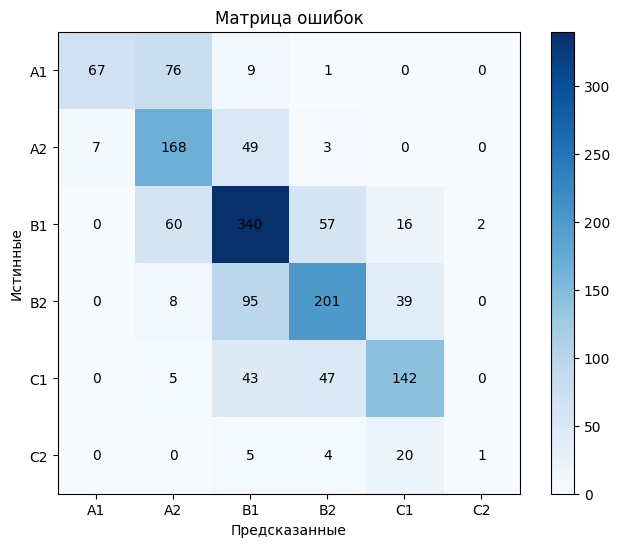

In [39]:
visualize_cm(true_labels, predictions)

# Температура 1.0

In [40]:
c2 = pd.read_csv('c2_generated_llama3_temp_1_0.csv')
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,1.029500,0.959914
2,0.536700,1.046074
3,0.143200,1.454659


Обучение завершено за 328.45 секунд (0:05:28)


In [41]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6089
F1 Micro: 0.6089
F1 Macro: 0.5236
F1 Weighted: 0.6021
MAE: 0.4621
              precision    recall  f1-score   support

           1       0.90      0.41      0.57       153
           2       0.52      0.74      0.61       227
           3       0.61      0.69      0.65       475
           4       0.61      0.56      0.58       343
           5       0.63      0.59      0.61       237
           6       0.67      0.07      0.12        30

    accuracy                           0.61      1465
   macro avg       0.66      0.51      0.52      1465
weighted avg       0.63      0.61      0.60      1465



0.6089
0.6089
0.5236
0.6021
0.4621
328.45


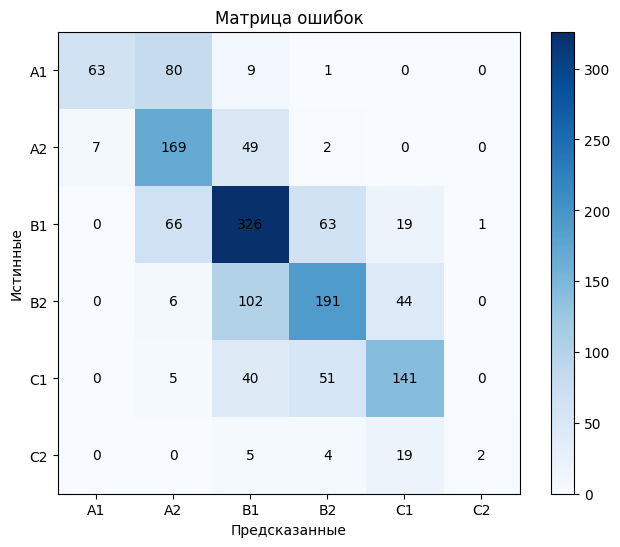

In [42]:
visualize_cm(true_labels, predictions)

# Температура 1.1

In [43]:
c2 = pd.read_csv('c2_generated_llama3_temp_1_1.csv')
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,1.024700,0.964868
2,0.535400,1.078303
3,0.143400,1.483044


Обучение завершено за 328.33 секунд (0:05:28)


In [44]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6123
F1 Micro: 0.6123
F1 Macro: 0.5152
F1 Weighted: 0.6042
MAE: 0.4635
              precision    recall  f1-score   support

           1       0.91      0.41      0.57       153
           2       0.52      0.74      0.61       227
           3       0.61      0.72      0.66       475
           4       0.63      0.56      0.59       343
           5       0.65      0.57      0.60       237
           6       0.50      0.03      0.06        30

    accuracy                           0.61      1465
   macro avg       0.64      0.50      0.52      1465
weighted avg       0.63      0.61      0.60      1465



0.6123
0.6123
0.5152
0.6042
0.4635
328.33


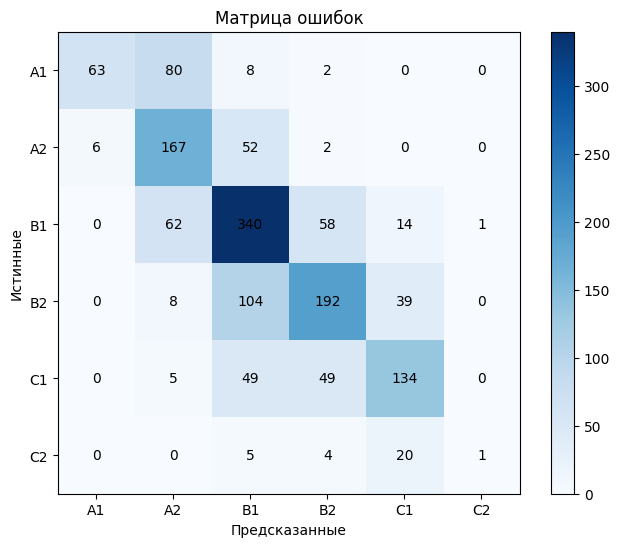

In [45]:
visualize_cm(true_labels, predictions)

# Температура 1.2

In [46]:
c2 = pd.read_csv('c2_generated_llama3_temp_1_2.csv')
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,1.026200,0.959367
2,0.526400,1.035378
3,0.129000,1.430306


Обучение завершено за 327.99 секунд (0:05:27)


In [47]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6266
F1 Micro: 0.6266
F1 Macro: 0.5440
F1 Weighted: 0.6213
MAE: 0.4471
              precision    recall  f1-score   support

           1       0.92      0.44      0.59       153
           2       0.53      0.77      0.63       227
           3       0.63      0.71      0.67       475
           4       0.65      0.57      0.60       343
           5       0.65      0.60      0.62       237
           6       0.27      0.10      0.15        30

    accuracy                           0.63      1465
   macro avg       0.61      0.53      0.54      1465
weighted avg       0.65      0.63      0.62      1465



0.6266
0.6266
0.5440
0.6213
0.4471
327.99


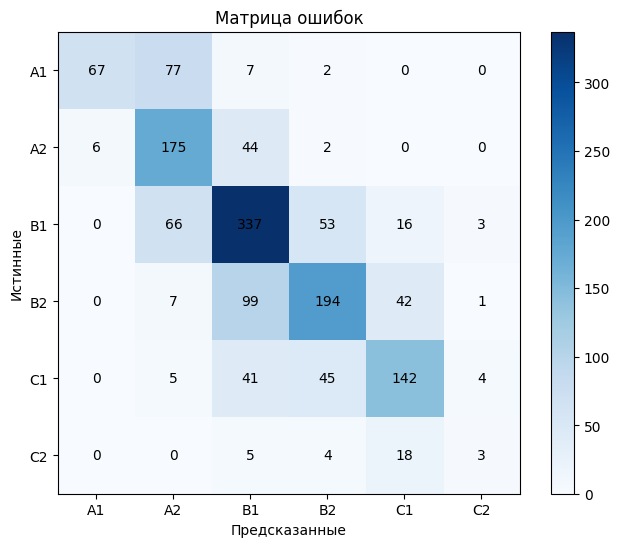

In [48]:
visualize_cm(true_labels, predictions)

# Температура 1.3

In [49]:
c2 = pd.read_csv('c2_generated_llama3_temp_1_3.csv')
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,1.033600,0.970537
2,0.524300,1.020110
3,0.131700,1.434374


Обучение завершено за 328.24 секунд (0:05:28)


In [50]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6102
F1 Micro: 0.6102
F1 Macro: 0.5248
F1 Weighted: 0.6033
MAE: 0.4635
              precision    recall  f1-score   support

           1       0.91      0.42      0.57       153
           2       0.51      0.79      0.62       227
           3       0.63      0.68      0.65       475
           4       0.61      0.55      0.58       343
           5       0.64      0.57      0.60       237
           6       0.50      0.07      0.12        30

    accuracy                           0.61      1465
   macro avg       0.63      0.51      0.52      1465
weighted avg       0.63      0.61      0.60      1465



0.6102
0.6102
0.5248
0.6033
0.4635
328.24


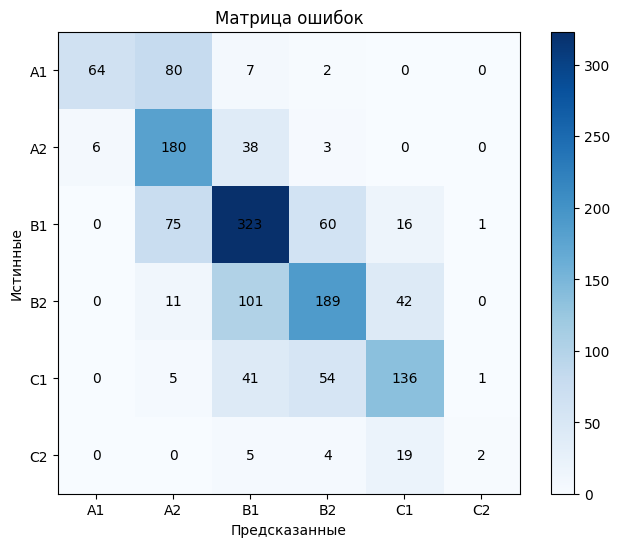

In [51]:
visualize_cm(true_labels, predictions)

# Температура 1.4

In [52]:
c2 = pd.read_csv('c2_generated_llama3_temp_1_4.csv')
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,1.063900,1.015649
2,0.650300,1.008632
3,0.237000,1.243388


Обучение завершено за 328.31 секунд (0:05:28)


In [53]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6382
F1 Micro: 0.6382
F1 Macro: 0.6048
F1 Weighted: 0.6342
MAE: 0.4519
              precision    recall  f1-score   support

           1       0.77      0.76      0.77       153
           2       0.55      0.71      0.62       227
           3       0.60      0.73      0.66       475
           4       0.69      0.53      0.60       343
           5       0.70      0.51      0.59       237
           6       0.73      0.27      0.39        30

    accuracy                           0.64      1465
   macro avg       0.67      0.58      0.60      1465
weighted avg       0.65      0.64      0.63      1465



0.6382
0.6382
0.6048
0.6342
0.4519
328.31


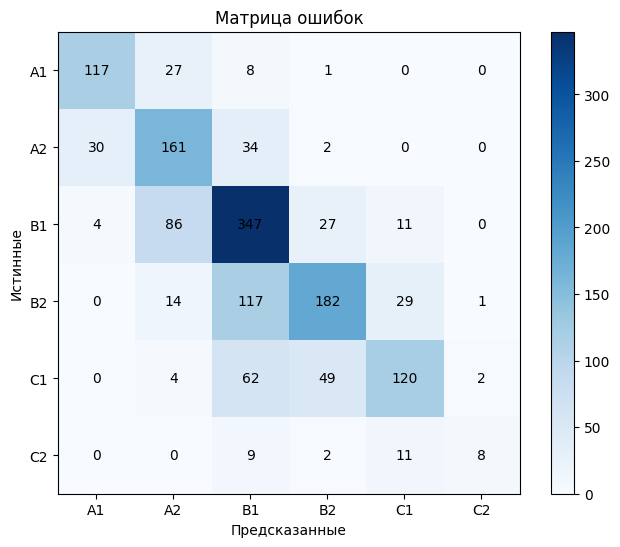

In [54]:
visualize_cm(true_labels, predictions)

# Температура 1.5

In [55]:
c2 = pd.read_csv('c2_generated_llama3_temp_1_5.csv')
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,1.026700,0.952476
2,0.532100,1.010672
3,0.124500,1.449331


Обучение завершено за 328.38 секунд (0:05:28)


In [56]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6246
F1 Micro: 0.6246
F1 Macro: 0.5350
F1 Weighted: 0.6188
MAE: 0.4471
              precision    recall  f1-score   support

           1       0.90      0.50      0.64       153
           2       0.53      0.77      0.63       227
           3       0.63      0.68      0.65       475
           4       0.62      0.59      0.61       343
           5       0.65      0.59      0.62       237
           6       1.00      0.03      0.06        30

    accuracy                           0.62      1465
   macro avg       0.72      0.53      0.53      1465
weighted avg       0.65      0.62      0.62      1465



0.6246
0.6246
0.5350
0.6188
0.4471
328.38


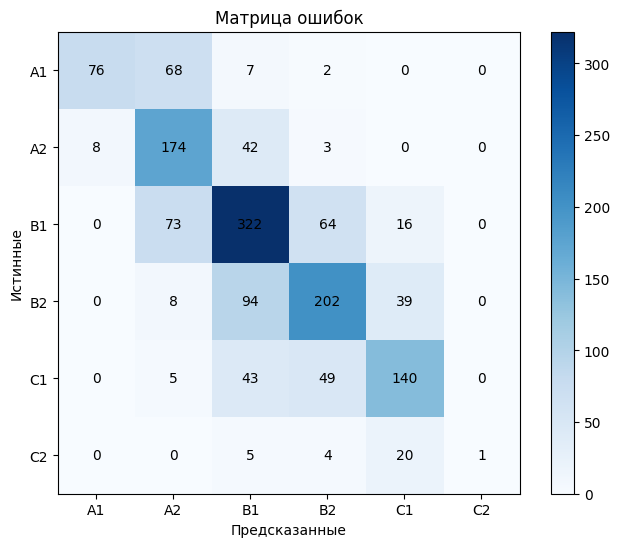

In [57]:
visualize_cm(true_labels, predictions)